# Notebook 02: AugMix Robustness Baseline

AugMix creates multiple stochastic augmentation chains, mixes them, and adds a Jensen-Shannon consistency penalty. This is a strong published baseline for common corruption robustness.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd
import torch
import matplotlib.pyplot as plt

from robust_cifar.data import make_cifar10_loaders, CIFAR10_CLASSES
from robust_cifar.models import build_resnet18_cifar, count_parameters
from robust_cifar.train import get_device, seed_everything

seed_everything(42)
device = get_device()
device

device(type='cuda')

## AugMix Loader

Each batch returns a clean image plus two AugMix views used for JSD consistency training.

In [2]:
train_loader, test_loader = make_cifar10_loaders(
    data_dir=PROJECT_ROOT / "data",
    batch_size=64,
    num_workers=2,
    mode="augmix",
    download=True,
)
batch = next(iter(train_loader))
[x.shape if hasattr(x, "shape") else len(x) for x in batch]

Files already downloaded and verified
Files already downloaded and verified


[torch.Size([64, 3, 32, 32]),
 torch.Size([64, 3, 32, 32]),
 torch.Size([64, 3, 32, 32]),
 torch.Size([64])]

## Train AugMix Model

In [3]:
from robust_cifar.train import train_augmix

model = build_resnet18_cifar()
EPOCHS = 100
history = train_augmix(
    model,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    lr=0.01,
    jsd_weight=12.0,
    device=device,
    output_dir=PROJECT_ROOT / "checkpoints",
    run_name="resnet18_augmix",
)
metrics_df = (
    pd.DataFrame(history)[["epoch", "train_loss", "train_accuracy", "val_loss", "val_accuracy"]]
    .rename(columns={"val_loss": "test_loss", "val_accuracy": "test_accuracy"})
)

for row in metrics_df.itertuples(index=False):
    print(
        f"Epoch {int(row.epoch):03d} | "
        f"Train Loss: {row.train_loss:.4f} | Train Acc: {row.train_accuracy:.4f} | "
        f"Test Loss: {row.test_loss:.4f} | Test Acc: {row.test_accuracy:.4f}"
    )

metrics_df

resnet18_augmix epoch 1/100:   0%|          | 0/782 [00:07<?, ?it/s]

resnet18_augmix epoch 2/100:   0%|          | 0/782 [00:07<?, ?it/s]

resnet18_augmix epoch 3/100:   0%|          | 0/782 [00:07<?, ?it/s]

resnet18_augmix epoch 4/100:   0%|          | 0/782 [00:07<?, ?it/s]

resnet18_augmix epoch 5/100:   0%|          | 0/782 [00:08<?, ?it/s]

...

resnet18_augmix epoch 98/100:   0%|          | 0/782 [00:09<?, ?it/s]

resnet18_augmix epoch 99/100:   0%|          | 0/782 [00:09<?, ?it/s]

resnet18_augmix epoch 100/100:   0%|          | 0/782 [00:11<?, ?it/s]

Epoch 001 | Train Loss: 1.8504 | Train Acc: 0.3933 | Test Loss: 1.3861 | Test Acc: 0.5127
Epoch 002 | Train Loss: 1.4797 | Train Acc: 0.5742 | Test Loss: 1.1456 | Test Acc: 0.5965
Epoch 003 | Train Loss: 1.2911 | Train Acc: 0.6592 | Test Loss: 0.8781 | Test Acc: 0.6958
Epoch 004 | Train Loss: 1.1491 | Train Acc: 0.7186 | Test Loss: 0.7659 | Test Acc: 0.7564
Epoch 005 | Train Loss: 1.0467 | Train Acc: 0.7622 | Test Loss: 0.6943 | Test Acc: 0.7829
Epoch 006 | Train Loss: 0.9642 | Train Acc: 0.7896 | Test Loss: 0.6256 | Test Acc: 0.8081
Epoch 007 | Train Loss: 0.9058 | Train Acc: 0.8099 | Test Loss: 0.5859 | Test Acc: 0.8167
Epoch 008 | Train Loss: 0.8507 | Train Acc: 0.8262 | Test Loss: 0.5381 | Test Acc: 0.8309
Epoch 009 | Train Loss: 0.8161 | Train Acc: 0.8387 | Test Loss: 0.5083 | Test Acc: 0.8464
Epoch 010 | Train Loss: 0.7788 | Train Acc: 0.8500 | Test Loss: 0.4929 | Test Acc: 0.8550
Epoch 011 | Train Loss: 0.7499 | Train Acc: 0.8591 | Test Loss: 0.4958 | Test Acc: 0.8462
Epoch 012 

,epoch,train_loss,train_accuracy,test_loss,test_accuracy
0,1,1.850437,0.39334,1.386086,0.5127
1,2,1.479689,0.57422,1.145633,0.5965
2,3,1.291135,0.65922,0.878126,0.6958
3,4,1.149101,0.71862,0.765902,0.7564
4,5,1.046679,0.76220,0.694283,0.7829
...,...,...,...,...,...
95,96,0.100159,0.99788,0.157039,0.9522
96,97,0.099152,0.99756,0.157580,0.9526
97,98,0.094298,0.99782,0.155441,0.9527
98,99,0.095243,0.99796,0.156404,0.9530


## Training and Testing Accuracy Comparison

The table above reports epoch, loss, and accuracy for both training and testing data. The graph below compares training accuracy against testing accuracy across epochs.

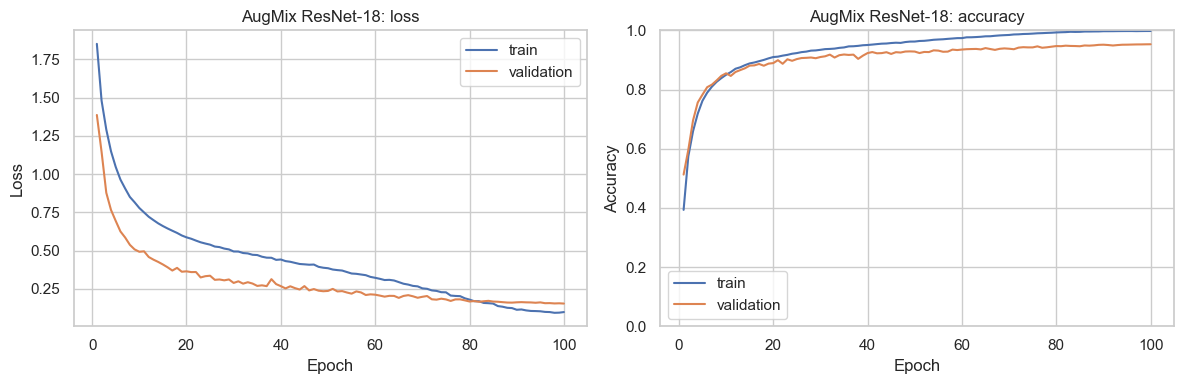

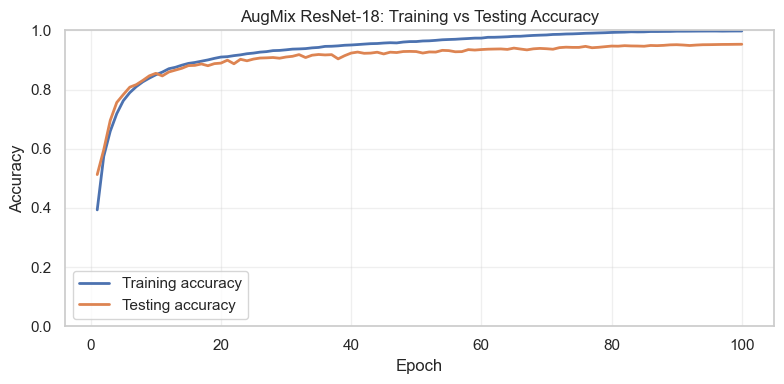

In [4]:
from robust_cifar.visualize import plot_training_history

history_df = pd.DataFrame(history)
plot_training_history(
    history_df,
    title="AugMix ResNet-18",
    output_path=PROJECT_ROOT / "reports" / "figures" / "augmix_training.png",
)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(metrics_df["epoch"], metrics_df["train_accuracy"], label="Training accuracy", linewidth=2)
ax.plot(metrics_df["epoch"], metrics_df["test_accuracy"], label="Testing accuracy", linewidth=2)
ax.set_title("AugMix ResNet-18: Training vs Testing Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "reports" / "figures" / "augmix_train_test_accuracy.png", dpi=180, bbox_inches="tight")
plt.show()